# LPT Lightcone with Stacked Shells

This notebook demonstrates building lightcones by computing LPT at multiple scale factors and stacking the resulting density projections. The key features:

1. Compute scale factors for lightcone shells using `compute_snapshot_scale_factors()`
2. Single batched LPT call with array of scale factors
3. Stack flat-sky projections with `FlatDensity.stack()`
4. Stack spherical projections with `SphericalDensity.stack()`

## Setup and Imports

In [2]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["JAX_PLATFORMS"] = "cpu"

import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax_cosmo as jc
import numpy as np

from fwd_model_tools.field import FieldStatus, ParticleField, FlatDensity, SphericalDensity
from fwd_model_tools.normal import gaussian_initial_conditions
from fwd_model_tools.pm import lpt
from fwd_model_tools.utils import compute_lpt_lightcone_scale_factors
from fwd_model_tools.lensing_model import Planck18

mesh_size = (256 , 256, 256)
box_size = (1000.0, 1000.0, 1000.0)
observer_position = (0.5, 0.5, 0.5)

## Generate Initial Conditions

Create Gaussian initial conditions

In [3]:
key = jax.random.PRNGKey(42)
cosmo = Planck18()
gaussian_field = gaussian_initial_conditions(
    key=key,
    cosmo=cosmo,
    mesh_size=mesh_size,
    box_size=box_size,
    observer_position=observer_position,
    nside=256,
    flatsky_npix=(256, 256),
)

print(f"Initial field: {gaussian_field}")
print(f"Status: {gaussian_field.status}")

Initial field: DensityField(array=Array(256, 256, 256), mesh_size=(256, 256, 256), box_size=(1000.0, 1000.0, 1000.0), status=initial_field, scale_factors_shape=(1,))
Status: FieldStatus.INITIAL_FIELD


## Compute Lightcone Shell Scale Factors

Use `compute_snapshot_scale_factors()` to compute scale factors at which to evaluate LPT for each shell.

In [4]:
cosmo = Planck18()

scale_factors = compute_lpt_lightcone_scale_factors(cosmo, gaussian_field)
r_centers = jc.background.radial_comoving_distance(cosmo, scale_factors)

## Batched LPT Computation

Single call to `lpt()` with array of scale factors returns batched ParticleFields with shape `(N, X, Y, Z, 3)`.

In [5]:
dx_lightcone, p_lightcone = lpt(cosmo, gaussian_field, a=scale_factors, order=1)

print(f"Displacement field: {dx_lightcone}")
print(f"Array shape: {dx_lightcone.array.shape}")

shape of initial force: (256, 256, 256, 3)
growth factor shape: (1, 1, 256, 1)
Displacement field: ParticleField(array=Array(256, 256, 256, 3), mesh_size=(256, 256, 256), box_size=(1000.0, 1000.0, 1000.0), status=lpt1, scale_factors_shape=(1, 1, 256, 1))
Array shape: (256, 256, 256, 3)


## Test All Painting Methods

Demonstrate painting batched ParticleField to:
1. 3D density grid
2. 2D flat-sky projection
3. HEALPix spherical projection

In [9]:
# Paint to 3D density grid
density_3d = dx_lightcone.paint()
print(f"3D Density: {density_3d}")
print(f"Shape: {density_3d.array.shape}")

3D Density: DensityField(array=Array(256, 256, 256), mesh_size=(256, 256, 256), box_size=(1000.0, 1000.0, 1000.0), status=density_field, scale_factors_shape=(1, 1, 256, 1))
Shape: (256, 256, 256)


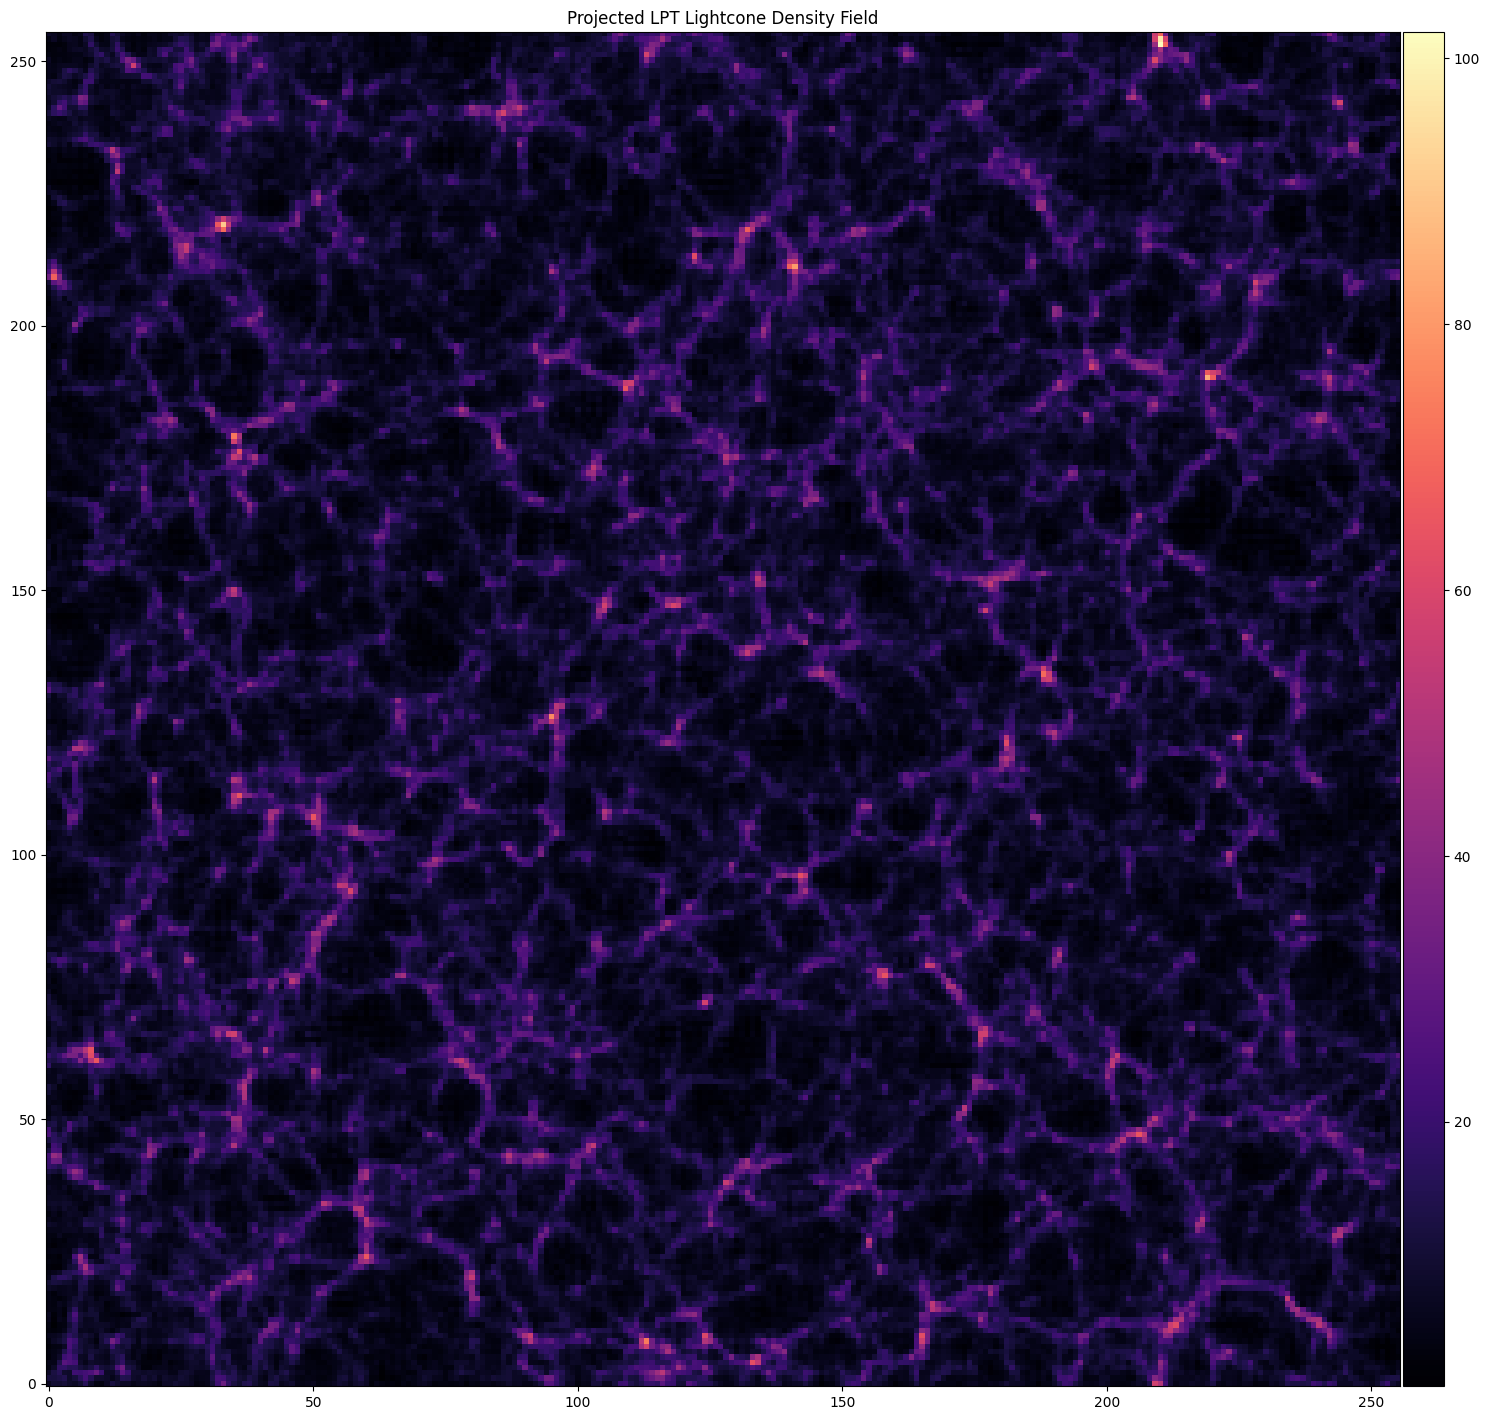

In [22]:
# Visualize 2D projection of 3D density
density_3d.project().show(titles=[f"Projected LPT Lightcone Density Field"] , figsize=(15 , 15))

## Stack Spherical Projections

Extract each shell, paint to HEALPix, and stack.

In [12]:
dx_lightcone.max_comoving_radius

np.float64(500.0)

Spherical lightcone: SphericalDensity(array=Array(786432,), mesh_size=(256, 256, 256), box_size=(1000.0, 1000.0, 1000.0), status=lightcone, scale_factors_shape=(1, 1, 256, 1))
Shape: (786432,)


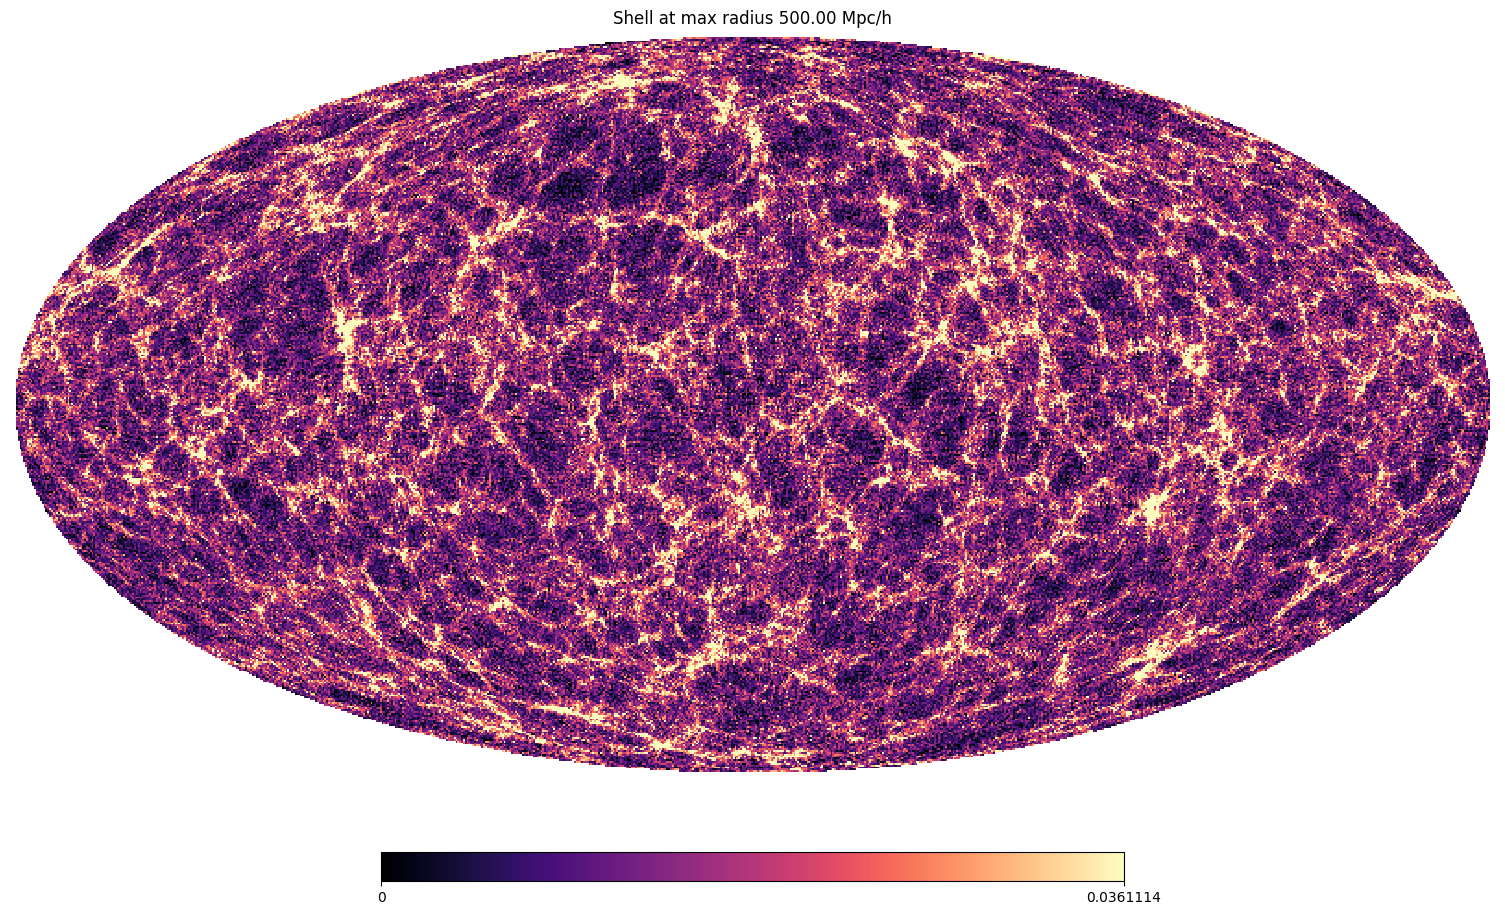

In [24]:
# Paint to HEALPix spherical
sph_lightcone = dx_lightcone.paint_spherical(center=dx_lightcone.max_comoving_radius / 2, scheme="rbf_neighbor" , density_plane_width=100.0 , paint_nside=512 , kernel_width_arcmin=20.0)

print(f"Spherical lightcone: {sph_lightcone}")
print(f"Shape: {sph_lightcone.array.shape}")

# Visualize
sph_lightcone.show(figsize=(15 , 15),titles=[f"Shell at max radius {dx_lightcone.max_comoving_radius:.2f} Mpc/h"])